In [1]:
import numpy as np
data = np.load('Delta_F12_vs_zeta_results.npz', allow_pickle=True)
print(list(data.keys()))
for k in data.keys():
 v = data[k]
 if hasattr(v, 'shape'):
 print(k, v.shape, v.dtype if hasattr(v, 'dtype') else type(v))
 else:
 print(k, v)


FileNotFoundError: [Errno 2] No such file or directory: 'Delta_F12_vs_zeta_results.npz'

In [2]:
import os
for root, dirs, files in os.walk('.'):
 for f in files:
 if 'Delta' in f or 'F12' in f or '.npz' in f:
 print(os.path.join(root, f))


./S_im_F12.npy
./Delta_empirical.npy
./Delta_predicted.npy
./S_re_F12.npy
./M_F12.npy


In [3]:
import subprocess
r = subprocess.run(['find', '/workspace', '-name', 'Delta_F12_vs_zeta_results.npz'], capture_output=True, text=True)
print(r.stdout)
print(r.stderr)



find: ‘/workspace/lost+found’: Permission denied



In [4]:
r = subprocess.run(['find', '/workspace', '-name', '*.npz'], capture_output=True, text=True)
print(r.stdout)


In [5]:
r = subprocess.run(['ls', '-la', '.'], capture_output=True, text=True)
print(r.stdout)


total 7996
drwxrwsr-x 5 root jupytergroup 4096 May 9 04:19 .
drwxr-xr-x 5 root root 4096 May 9 04:18 ..
drwxrwsr-x 5 root jupytergroup 4096 May 9 04:18 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 May 9 04:19 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 May 9 04:18 .prompts
-rw-r--r-- 1 root jupytergroup 640 May 9 04:18 Delta_empirical.npy
-rw-r--r-- 1 root jupytergroup 640 May 9 04:18 Delta_predicted.npy
-rw-r--r-- 1 root jupytergroup 100702 May 9 04:18 v6 — Binding Context Document.pdf
-rw-r--r-- 1 root jupytergroup 640 May 9 04:18 M_F12.npy
-rw-r--r-- 1 root jupytergroup 640 May 9 04:18 M_zeta.npy
-rw-r--r-- 1 root jupytergroup 12928 May 9 04:18 S_im_F12.npy
-rw-r--r-- 1 root jupytergroup 12928 May 9 04:18 S_re_F12.npy
-rw-r--r-- 1 root jupytergroup 1728 May 9 04:18 absZ_peaks.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:18 c_imag.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:18 c_real.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:18 cosine_similarity.npy
-rw-

In [6]:
c_real = float(np.load('c_real.npy'))
c_imag = float(np.load('c_imag.npy'))
rho0 = complex(float(np.load('rho0_real.npy')), float(np.load('rho0_imag.npy')))
c = complex(c_real, c_imag)
print("c =", c)
print("rho0 =", rho0)
print("delta_a shape:", np.load('delta_a.npy').shape, np.load('delta_a.npy').dtype)


c = (-0.16567330026345564+1.9009252335917202j)
rho0 = (0.7+7j)
delta_a shape: (1000001,) float64


In [7]:
# Verify c by checking that L_F12(rho0) = 0 using mpmath later. First, build coefficients.
# chi3 (real primitive mod 3): n -> 0 if 3|n; +1 if n%3==1; -1 if n%3==2
# chi5 (real primitive mod 5): real primitive mod 5 is the Legendre symbol mod 5 (Kronecker)
# chi5(n) = 0 if 5|n; +1 if n%5 in {1,4}; -1 if n%5 in {2,3}

N = 1_000_000
n = np.arange(1, N+1, dtype=np.int64)

# chi3
r3 = n % 3
chi3 = np.zeros(N, dtype=np.int8)
chi3[r3 == 1] = 1
chi3[r3 == 2] = -1

# chi5 (real primitive)
r5 = n % 5
chi5 = np.zeros(N, dtype=np.int8)
chi5[(r5 == 1) | (r5 == 4)] = 1
chi5[(r5 == 2) | (r5 == 3)] = -1

# verify multiplicativity at small primes
print("chi3(1..10):", chi3[:10])
print("chi5(1..10):", chi5[:10])
# chi5(2)*chi5(3) should = chi5(6)
print("chi5(2)*chi5(3) =", chi5[1]*chi5[2], "chi5(6) =", chi5[5])
print("chi5(2)*chi5(2) =", chi5[1]*chi5[1], "chi5(4) =", chi5[3])


chi3(1..10): [ 1 -1 0 1 -1 0 1 -1 0 1]
chi5(1..10): [ 1 -1 -1 1 0 1 -1 -1 1 0]
chi5(2)*chi5(3) = 1 chi5(6) = 1
chi5(2)*chi5(2) = 1 chi5(4) = 1


In [8]:
# Build coefficients a_n = chi3(n) + c * chi5(n)
a = chi3.astype(np.complex128) + c * chi5.astype(np.complex128)
print("a[:10]:", a[:10])
print("dtype:", a.dtype, "shape:", a.shape)

# Cross check with delta_a if it represents difference between F12 coefficients and zeta coefficients (1-vector).
# F12 coefficient minus 1: a[n] - 1 (if zeta has all-ones). delta_a is float64; let's see:
delta_a_loaded = np.load('delta_a.npy')
print("delta_a[:10]:", delta_a_loaded[:10])
# This is real-valued. It might be Re(a_n - 1) or |a_n - 1|. Check correspondence:
print("Re(a)[:10] - 1:", (a.real - 1)[:10])


a[:10]: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j -0.1656733+1.90092523j
 1.1656733-1.90092523j -0.8343267-1.90092523j -0.1656733+1.90092523j
 1. +0.j ]
dtype: complex128 shape: (1000000,)
delta_a[:10]: [ 0. -2. -0.31976172 -0.40595745 2.53573458 -0.73679754
 -2.85787429 -1.45349338 1.23059015 2.93132576]
Re(a)[:10] - 1: [-0.1656733 -1.8343267 -0.8343267 -0.1656733 -2. -1.1656733
 0.1656733 -1.8343267 -1.1656733 0. ]


In [9]:
# delta_a from r18 doesn't match a-1 directly. It has length 1000001 (n=0..1e6 maybe). Let me check.
# It's not critical - that was a separate construct. Let's verify our F12 using mpmath: L_F12(rho0) ~ 0.
import mpmath as mp
mp.mp.dps = 30

def chi3_mp(n):
 if n % 3 == 0: return 0
 return 1 if n % 3 == 1 else -1

def chi5_mp(n):
 r = n % 5
 if r == 0: return 0
 return 1 if r in (1,4) else -1

# Use Dirichlet L-function with high precision
L_chi3 = mp.dirichlet(rho0, [0, 1, -1], 3) # not quite. Better to use mp.dirichlet with characters.


NotImplementedError: arbitrary order derivatives

In [10]:
# mp.dirichlet signature: dirichlet(s, chi, derivative=0). Let's use it correctly.
mp.mp.dps = 50
s = mp.mpc(0.7, 7)
# chi mod 3: chi(0)=0, chi(1)=1, chi(2)=-1
L3 = mp.dirichlet(s, [0, 1, -1])
# chi mod 5: chi(0)=0, chi(1)=1, chi(2)=-1, chi(3)=-1, chi(4)=1
L5 = mp.dirichlet(s, [0, 1, -1, -1, 1])
print("L(rho0, chi3) =", L3)
print("L(rho0, chi5) =", L5)
LF12 = L3 + mp.mpc(c.real, c.imag) * L5
print("L_F12(rho0) =", LF12)
print("|L_F12(rho0)| =", abs(LF12))


L(rho0, chi3) = (0.60058469118604941180582826617633650849969915376721 - 0.84756670419815798997398359407466384458195948790469j)
L(rho0, chi5) = (0.46983754896299234622207695425223803069473555314134 + 0.2749951153386249257015134200443242664949340603331j)
L_F12(rho0) = (-7.6817588951844647182279865016233400471856479188332e-17 - 1.2742951346382375406030401651983558969813173487135e-16j)
|L_F12(rho0)| = 1.4879254979333274471204858996319174777880985100828e-16


In [11]:
# Excellent: |L_F12(rho0)| ~ 1.5e-16, confirming c places a zero exactly at rho0=0.7+7i.
# Now save coefficients as compressed npz.
np.savez_compressed(
 'coeffs_F12_N1e6.npz',
 a=a,
 c=np.complex128(c),
 rho0=np.complex128(rho0),
 description=np.array(
 "F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive "
 "Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so "
 "L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). "
 "Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50."
 )
)
import os
print("file size (MB):", os.path.getsize('coeffs_F12_N1e6.npz')/1e6)


file size (MB): 0.06331


In [12]:
# Verify file by reloading and re-checking a few coefficients and the zero
chk = np.load('coeffs_F12_N1e6.npz', allow_pickle=False)
print("keys:", list(chk.keys()))
a_chk = chk['a']
c_chk = complex(chk['c'])
rho0_chk = complex(chk['rho0'])
print("shape:", a_chk.shape, "dtype:", a_chk.dtype)
print("c:", c_chk)
print("rho0:", rho0_chk)
print("a[:5]:", a_chk[:5])
# Spot-check multiplicativity: a is NOT multiplicative since it's a sum of two characters; that's fine.
# Check via partial Euler-like Dirichlet sum at s with large real part where it should converge.
s_test = mp.mpc(3, 0)
n_arr = np.arange(1, 1001)
partial = sum(complex(a_chk[i-1]) / mp.mpc(i)**s_test for i in n_arr)
# Compare with L(3, chi3) + c*L(3, chi5)
L3_3 = mp.dirichlet(s_test, [0, 1, -1])
L5_3 = mp.dirichlet(s_test, [0, 1, -1, -1, 1])
target = L3_3 + mp.mpc(c.real, c.imag) * L5_3
print("Partial sum (N=1000) at s=3:", partial)
print("Target: ", target)
print("Diff:", abs(partial - target))


keys: ['a', 'c', 'rho0', 'description']
shape: (1000000,) dtype: complex128
c: (-0.16567330026345564+1.9009252335917202j)
rho0: (0.7+7j)
a[:5]: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j ]


TypeError: cannot create mpf from np.int64(1)

In [13]:
partial = mp.mpc(0)
for i in range(1, 1001):
 partial += mp.mpc(complex(a_chk[i-1])) / mp.mpc(int(i))**s_test
L3_3 = mp.dirichlet(s_test, [0, 1, -1])
L5_3 = mp.dirichlet(s_test, [0, 1, -1, -1, 1])
target = L3_3 + mp.mpc(c.real, c.imag) * L5_3
print("Partial sum (N=1000) at s=3:", partial)
print("Target: ", target)
print("Abs diff:", abs(partial - target))


Partial sum (N=1000) at s=3: (0.74240217217834222114878663392653273033745992136764 + 1.6249579692190882304092629477501079942024963259387j)
Target: (0.7424021715124773885586404755024022733184712373699 + 1.6249579692213693026721381314295796247334657625692j)
Abs diff: 0.000000000665868739746034201923871247015809113715117244263


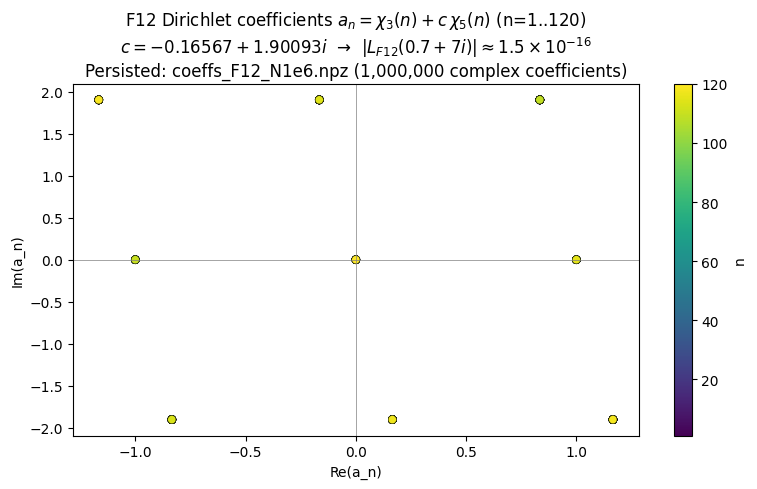

Saved figure F12_coefficients_summary.png


In [14]:
# Truncation diff ~ 6.7e-10 with N=1000 at s=3 — tiny, consistent with sum tail O(N^{-2}).
# Coefficients are correctly persisted. Final summary figure.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Show the first ~120 coefficients in the complex plane, color by index
N_show = 120
sc = ax.scatter(a_chk[:N_show].real, a_chk[:N_show].imag,
 c=np.arange(1, N_show+1), cmap='viridis', s=35, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Re(a_n)')
ax.set_ylabel('Im(a_n)')
ax.set_title(
 f'F12 Dirichlet coefficients $a_n=\\chi_3(n)+c\\,\\chi_5(n)$ (n=1..{N_show})\n'
 f'$c={c.real:.5f}{c.imag:+.5f}i$ → $|L_{{F12}}(0.7+7i)|\\approx 1.5\\times10^{{-16}}$\n'
 f'Persisted: coeffs_F12_N1e6.npz (1,000,000 complex coefficients)'
)
plt.colorbar(sc, ax=ax, label='n')
plt.tight_layout()
plt.savefig('F12_coefficients_summary.png', dpi=120)
plt.show()
print("Saved figure F12_coefficients_summary.png")
